# Support Vector Machine

## Setup 

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import roc_curve

In [2]:
try:
    X_train = joblib.load("X_train.pkl")
    X_test = joblib.load("X_test.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test :", X_test.shape, "y_test :", y_test.shape)

Loaded successfully
X_train: (3996, 42) y_train: (3996,)
X_test : (1000, 42) y_test : (1000,)


## Results Log 
Tracks accuracy at every stage of the notebook (baseline, tuning, cross-validation, etc.) so improvements can be compared side by side rather than only seeing the most recently printed number.

In [3]:
results_log = []

def log_result(name, y_true, y_pred):
    """Log accuracy from a set of predictions."""
    try:
        acc = accuracy_score(y_true, y_pred)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc})
    print(f"[Logged] {name}: {acc:.4f}")
    return acc

def log_value(name, acc):
    """Log an already-computed accuracy value (e.g. a CV mean)."""
    try:
        acc = float(acc)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc})
    print(f"[Logged] {name}: {acc:.4f}")
    return acc

## Baseline Model
Default hyperparameters are used before optimization.

In [4]:
try:
    svm = SVC(random_state=42, probability=True)
    svm.fit(X_train, y_train)
    svm_pred = svm.predict(X_test)
except (ValueError, RuntimeError) as e:
    print(f"Error training baseline SVM model: {e}")
else:
    svm_accuracy = accuracy_score(y_test, svm_pred)
    print("Baseline Accuracy:", svm_accuracy)
    print(classification_report(y_test, svm_pred))
    log_result("Baseline (default SVC)", y_test, svm_pred)

Baseline Accuracy: 0.788
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       438
           1       0.79      0.84      0.82       562

    accuracy                           0.79      1000
   macro avg       0.79      0.78      0.78      1000
weighted avg       0.79      0.79      0.79      1000

[Logged] Baseline (default SVC): 0.7880


## Hyperparameter Tuning
Grid Search evaluates different values of `C`, `kernel`, and `gamma` to determine the optimal combination of hyperparameters for the SVM model. \nCross-validation is standardised to **10-fold** throughout this notebook, for consistency with the other models.

In [5]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"],
}

try:
    grid_search = GridSearchCV(
        SVC(random_state=42, probability=True),
        param_grid,
        cv=10,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
except (ValueError, RuntimeError) as e:
    print(f"Error during Grid Search: {e}")
else:
    best_svm = grid_search.best_estimator_
    print("Best Parameters:", grid_search.best_params_)
    print("Best CV Accuracy:", grid_search.best_score_)
    log_value("Grid Search (10-fold CV, best score)", grid_search.best_score_)

    best_parameters = pd.DataFrame({
        "Parameter": grid_search.best_params_.keys(),
        "Best Value": grid_search.best_params_.values()
    })

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'poly'}
Best CV Accuracy: 0.8130626566416039
[Logged] Grid Search (10-fold CV, best score): 0.8131


In [6]:
best_parameters

,Parameter,Best Value
0,C,1
1,gamma,scale
2,kernel,poly


## Best Model Evaluation
The optimized SVM model obtained from Grid Search is evaluated using the testing dataset, including a confusion matrix to visualize classification performance.

In [7]:
try:
    best_pred = best_svm.predict(X_test)
    best_accuracy = accuracy_score(y_test, best_pred)
except (ValueError, RuntimeError, NameError) as e:
    print(f"Error evaluating best model: {e}")
else:
    print("Testing Accuracy:", best_accuracy)
    print(classification_report(y_test, best_pred))
    log_result("Grid Search Tuned (test set)", y_test, best_pred)

Testing Accuracy: 0.795
              precision    recall  f1-score   support

           0       0.77      0.75      0.76       438
           1       0.81      0.83      0.82       562

    accuracy                           0.80      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.80      0.79      1000

[Logged] Grid Search Tuned (test set): 0.7950


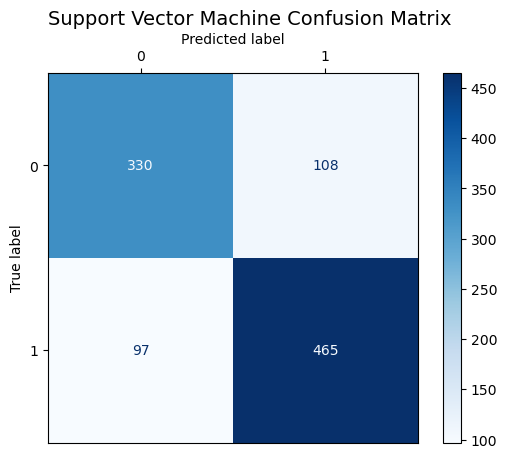

In [8]:
try:
    ConfusionMatrixDisplay.from_estimator(
        best_svm,
        X_test,
        y_test,
        cmap="Blues"
    )

    plt.title("Support Vector Machine Confusion Matrix", fontsize=14, loc='left')
    plt.gca().xaxis.tick_top()
    plt.gca().xaxis.set_label_position("top")
    plt.xlabel("Predicted label", fontsize=10)
    plt.ylabel("True label", fontsize=10)

    plt.show()
except (ValueError, NameError) as e:
    print(f"Error plotting confusion matrix: {e}")

## Model Stability — 10-Fold Cross-Validation 

[0.8175     0.81       0.8175     0.8125     0.8225     0.8
 0.82205514 0.82706767 0.81203008 0.78947368]
Average Accuracy: 0.8130626566416039
Standard Deviation: 0.010692445312292423
[Logged] 10-Fold Cross-Validation (mean): 0.8131


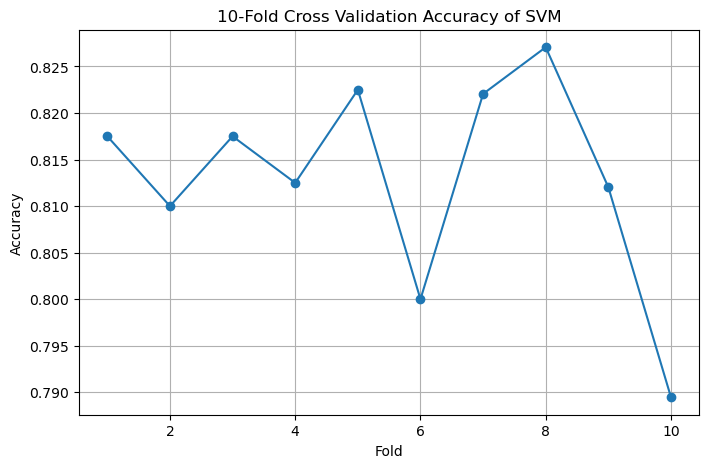

In [9]:
try:
    scores = cross_val_score(best_svm, X_train, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during cross-validation: {e}")
else:
    print(scores)
    print("Average Accuracy:", scores.mean())
    print("Standard Deviation:", scores.std())
    log_value("10-Fold Cross-Validation (mean)", scores.mean())

    cv_results = pd.DataFrame({
        "Fold": range(1, 11),
        "Accuracy": scores
    })

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 11), scores, marker='o')
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.title("10-Fold Cross Validation Accuracy of SVM")
    plt.grid(True)
    plt.show()

In [10]:
cv_results

,Fold,Accuracy
0,1,0.817500
1,2,0.810000
2,3,0.817500
3,4,0.812500
4,5,0.822500
5,6,0.800000
6,7,0.822055
7,8,0.827068
8,9,0.812030
9,10,0.789474


## Youden's J Statistic (Decision Threshold Optimisation)

In [11]:
try:
    y_probs = best_svm.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    y_pred_optimal = (y_probs >= best_threshold).astype(int)
except (ValueError, AttributeError, RuntimeError) as e:
    print(f"Error during threshold optimization: {e}")
else:
    print(f"Optimal threshold: {best_threshold:.4f}")
    print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")
    print("\nAccuracy with optimal threshold:", accuracy_score(y_test, y_pred_optimal))
    print(classification_report(y_test, y_pred_optimal))
    log_result("Grid Search + Youden's J", y_test, y_pred_optimal)

Optimal threshold: 0.6732
Youden's J at this threshold: 0.6259

Accuracy with optimal threshold: 0.807
              precision    recall  f1-score   support

           0       0.74      0.86      0.80       438
           1       0.88      0.77      0.82       562

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.81      0.81      1000

[Logged] Grid Search + Youden's J: 0.8070


## Balanced Class Weighting
SVM's model-specific \"extra formula\": by default, every training point contributes equally to the margin optimization, which can bias the boundary toward the majority class when classes aren't perfectly balanced. `class_weight='balanced'` reweights each class's contribution using: $$w_c = \\frac{n_{samples}}{n_{classes} \\times n_c}$$ where $n_c$ is the number of samples in class $c$. This makes the minority class's misclassifications penalized more heavily during training, which can shift the decision boundary to be fairer across classes.

In [12]:
try:
    svm_balanced = SVC(
        C=grid_search.best_params_['C'],
        kernel=grid_search.best_params_['kernel'],
        gamma=grid_search.best_params_['gamma'],
        class_weight='balanced',
        probability=True,
        random_state=42
    )
    svm_balanced.fit(X_train, y_train)
    balanced_pred = svm_balanced.predict(X_test)
except (ValueError, RuntimeError) as e:
    print(f"Error training balanced SVM: {e}")
else:
    balanced_accuracy = accuracy_score(y_test, balanced_pred)
    print("Balanced Class Weighting Accuracy:", balanced_accuracy)
    print(classification_report(y_test, balanced_pred))
    log_result("Balanced Class Weighting", y_test, balanced_pred)

Balanced Class Weighting Accuracy: 0.805
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       438
           1       0.84      0.81      0.82       562

    accuracy                           0.81      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.81      0.81      0.81      1000

[Logged] Balanced Class Weighting: 0.8050


## Additional Diagnostics
Training-vs-testing accuracy checks for overfitting/underfitting, a kernel comparison shows how different kernels perform against each other, and the support vector count shows how many training points define the decision boundary for each class.

In [13]:
# training vs testing accuracy
try:
    train_pred = best_svm.predict(X_train)
    test_pred = best_svm.predict(X_test)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
except (ValueError, RuntimeError) as e:
    print(f"Error computing train/test accuracy: {e}")
else:
    comparison = pd.DataFrame({
        "Dataset": ["Training", "Testing"],
        "Accuracy": [train_acc, test_acc]
    })
    print(comparison, "\n")
    log_value("Post-Tuning Training Accuracy", train_acc)

# kernel comparison
kernels = ["linear", "rbf", "poly"]
kernel_result = []

for kernel in kernels:
    try:
        model = SVC(kernel=kernel, random_state=42)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    except (ValueError, RuntimeError) as e:
        print(f"Error training kernel '{kernel}': {e}")
        continue
    acc = accuracy_score(y_test, pred)
    kernel_result.append({"Kernel": kernel, "Accuracy": acc})
    log_value(f"Kernel Comparison: {kernel}", acc)

kernel_result = pd.DataFrame(kernel_result)
print(kernel_result, "\n")

# number of support vectors per class
try:
    print("Support Vectors for Each Class:", best_svm.n_support_)
except AttributeError as e:
    print(f"Support vector info not available: {e}")

    Dataset  Accuracy
0  Training  0.851351
1   Testing  0.795000 

[Logged] Post-Tuning Training Accuracy: 0.8514
[Logged] Kernel Comparison: linear: 0.7630
[Logged] Kernel Comparison: rbf: 0.7880
[Logged] Kernel Comparison: poly: 0.7950
   Kernel  Accuracy
0  linear     0.763
1     rbf     0.788
2    poly     0.795 

Support Vectors for Each Class: [1052 1099]


## Model Complexity Curve — Accuracy vs. C 
As explained in Section 5, `SVC` doesn't expose a per-iteration loss curve. This plot is the closest honest equivalent: it sweeps `C` (the regularization strength in SVM's hinge-loss objective) and shows how accuracy responds — a small `C` allows a wider margin with more tolerated violations (risk of underfitting), while a large `C` fits the training data more tightly (risk of overfitting). This shows the same margin-vs-error tradeoff a loss curve would, from the outside.

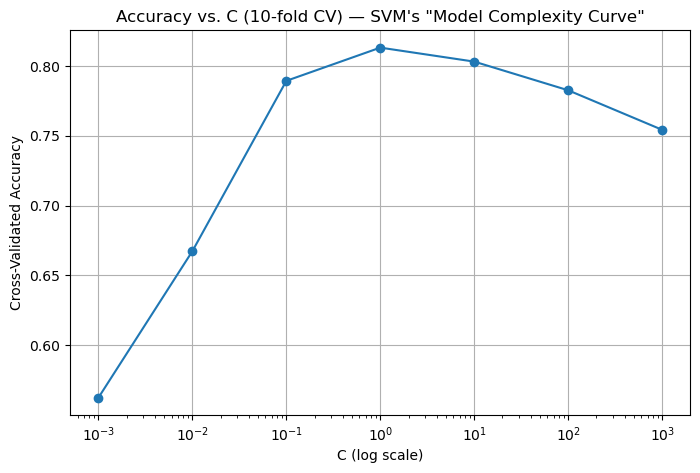

In [14]:
best_kernel = grid_search.best_params_['kernel']
best_gamma = grid_search.best_params_['gamma']

C_range = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
C_scores = []

try:
    for c_val in C_range:
        temp_svm = SVC(C=c_val, kernel=best_kernel, gamma=best_gamma, random_state=42)
        cv_result = cross_val_score(temp_svm, X_train, y_train, cv=10, scoring="accuracy")
        C_scores.append(cv_result.mean())
except (ValueError, RuntimeError) as e:
    print(f"Error during C sweep: {e}")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(C_range, C_scores, marker="o")
    plt.xscale("log")
    plt.title("Accuracy vs. C (10-fold CV) — SVM's \"Model Complexity Curve\"")
    plt.xlabel("C (log scale)")
    plt.ylabel("Cross-Validated Accuracy")
    plt.grid(True)
    plt.show()

## Result Summary & Save Model

In [15]:
summary = pd.DataFrame({
    "Metric": [
        "Best Kernel",
        "Best C",
        "Best Gamma",
        "Testing Accuracy",
        "Cross Validation Accuracy",
        "Cross Validation Std",
        "Training Accuracy"
    ],
    "Value": [
        grid_search.best_params_["kernel"],
        grid_search.best_params_["C"],
        grid_search.best_params_["gamma"],
        best_accuracy,
        scores.mean(),
        scores.std(),
        train_acc
    ]
})

summary

,Metric,Value
0,Best Kernel,poly
1,Best C,1
2,Best Gamma,scale
3,Testing Accuracy,0.795
4,Cross Validation Accuracy,0.813063
5,Cross Validation Std,0.010692
6,Training Accuracy,0.851351


## Full Accuracy Progression Log
Every stage's accuracy, in the order it was calculated — shows how (or whether) each technique actually improved on the previous stage.

In [16]:
log_df = pd.DataFrame(results_log)
log_df

,Stage,Accuracy
0,Baseline (default SVC),0.788000
1,"Grid Search (10-fold CV, best score)",0.813063
2,Grid Search Tuned (test set),0.795000
3,10-Fold Cross-Validation (mean),0.813063
4,Grid Search + Youden's J,0.807000
5,Balanced Class Weighting,0.805000
6,Post-Tuning Training Accuracy,0.851351
7,Kernel Comparison: linear,0.763000
8,Kernel Comparison: rbf,0.788000
9,Kernel Comparison: poly,0.795000


In [17]:
# save the trained model
try:
    joblib.dump(best_svm, 'svm_model.pkl')
except (OSError, PermissionError) as e:
    print(f"Error saving model: {e}")
else:
    print("Model saved successfully!")

Model saved successfully!
